In [ ]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
# Cell 1: Clean out conflicting packages
!pip uninstall -y torch torchvision torchaudio numpy
!pip cache purge

In [1]:
# Cell 2: Install compatible versions (very reliable on Kaggle Python 3.12 in 2026)
!pip install numpy==1.26.4 --no-cache-dir
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 222.8 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchmetrics 1.8.2 requires torch>=2.0.0, which is not installed.
easyocr 1.7.2 requires torch, which is not installed.
easyocr 1.7.2 requires torchvision>=0.5, which is not installed.
pytorch-lightning 2.6.0 requires torch>=2.1.0, which is not installed.
stable-baselines3 2.1.0 requires torch>=1.13, which is not installed.
accelerate 1.11.0 requires torch>=2.0.0, which is not installed.
sentence-transformers 5.1.1 requires torch>=1.11.0, which is not installed.
peft 0.17.1 requires torch>=1.13.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
fastai 2.8.4 requires torch<2.9,>

In [2]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())  # Should be True
print("CUDA version in torch:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())   # Should be 2 on T4 x2

Torch version: 2.5.1+cu121
CUDA available: True
CUDA version in torch: 12.1
Device count: 2


In [ ]:


import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from collections import Counter
import gradio as gr



In [4]:
nltk.download('punkt')



[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:

def find_image_dir():
    base_input = '/kaggle/input'
    for root, dirs, files in os.walk(base_input):
        if len([f for f in files if f.endswith('.jpg')]) > 1000:
            return root
    return None

IMAGE_DIR = find_image_dir()
OUTPUT_FILE = 'flickr30k_features.pkl'

if IMAGE_DIR:
    print(f"Found images at: {IMAGE_DIR}")
else:
    raise FileNotFoundError("Could not find the Flickr30k image directory. "
                            "Please ensure the dataset is added to the notebook.")


class FlickrDataset(Dataset):
    def __init__(self, img_dir, transform):
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg'))]
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, name)
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), name

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = nn.Sequential(*list(model.children())[:-1])  # remove classification head
model = nn.DataParallel(model).to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

dataset = FlickrDataset(IMAGE_DIR, transform)
loader = DataLoader(dataset, batch_size=128, num_workers=4, shuffle=False)

features_dict = {}
with torch.no_grad():
    for imgs, names in tqdm(loader, desc="Extracting Features"):
        feats = model(imgs.to(device)).view(imgs.size(0), -1)
        for i, name in enumerate(names):
            features_dict[name] = feats[i].cpu().numpy()

with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(features_dict, f)

print(f"Success! {len(features_dict)} images processed and saved to {OUTPUT_FILE}")

Found images at: /kaggle/input/datasets/adityajn105/flickr30k/Images


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]
Extracting Features: 100%|██████████| 249/249 [01:49<00:00,  2.27it/s]


Success! 31783 images processed and saved to flickr30k_features.pkl


In [30]:
import os
print(os.listdir('/kaggle/working'))

['flickr30k_features.pkl', '.virtual_documents']


In [ ]:

def load_captions(file_path):
    captions = {}

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if '\t' in line:
                parts = line.split('\t', 1)
            else:
                parts = line.split(' ', 1)

            if len(parts) != 2:
                continue

            image_part, caption = parts

            image_id = image_part.split('#')[0].strip().replace('"','').replace(',','')

            captions.setdefault(image_id, []).append(caption)

    return captions

captions_path = '/kaggle/input/datasets/adityajn105/flickr30k/captions.txt'  # Adjust if needed
raw_captions = load_captions(captions_path)



In [ ]:

captions = {}
for image, caps in raw_captions.items():
    captions[image] = ['<start> ' + c + ' <end>' for c in caps]

image_list = list(captions.keys())
random.seed(42)
random.shuffle(image_list)
train_images = image_list[:28000]
val_images = image_list[28000:29000]
test_images = image_list[29000:]

train_captions = {k: raw_captions[k] for k in train_images if k in raw_captions}
val_captions   = {k: raw_captions[k] for k in val_images if k in raw_captions}
test_captions  = {k: raw_captions[k] for k in test_images if k in raw_captions}




In [54]:
print("train_images:", len(train_images))
print("features_dict:", len(features_dict))
print("filtered train features:", len({k: features_dict[k] for k in train_images if k in features_dict}))
print("train_captions:", len(train_captions))
print("train_dataset:", len(train_dataset))

train_images: 28000
features_dict: 31783
filtered train features: 28000
train_captions: 28000
train_dataset: 114420


In [ ]:

class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.word2idx = {'<pad>': 0, '<start>': 1, '<end>': 2, '<unk>': 3}
        self.idx2word = {0: '<pad>', 1: '<start>', 2: '<end>', 3: '<unk>'}
        self.idx = 4
        self.freq_threshold = freq_threshold

    def build_vocab(self, captions_list):
        frequencies = Counter()
        for caps in captions_list.values():
            for cap in caps:
                frequencies.update(cap.lower().split())
        for word, count in frequencies.items():
            if count >= self.freq_threshold and word not in self.word2idx:
                self.word2idx[word] = self.idx
                self.idx2word[self.idx] = word
                self.idx += 1

    def numericalize(self, text):
        tokenized_text = text.lower().split()
        return [self.word2idx.get(word, self.word2idx['<unk>']) for word in tokenized_text]



In [ ]:
# Load features
with open('flickr30k_features.pkl', 'rb') as f:
    features_dict = pickle.load(f)


def clean_name(x):
    return x.strip().replace('"', '').replace(',', '')

train_images = [clean_name(x) for x in train_images]
val_images   = [clean_name(x) for x in val_images]
test_images  = [clean_name(x) for x in test_images]

# Now filtering will work correctly
train_features = {k: features_dict[k] for k in train_images if k in features_dict}
val_features   = {k: features_dict[k] for k in val_images if k in features_dict}
test_features  = {k: features_dict[k] for k in test_images if k in features_dict}

print("train_images:", len(train_images))
print("filtered train features:", len(train_features))

train_images: 28000
filtered train features: 28000


In [32]:
# vocab = Vocabulary()
# vocab.build_vocab(train_captions)
# vocab_size = len(vocab.word2idx)

# # Load features
# with open('flickr30k_features.pkl', 'rb') as f:
#     features_dict = pickle.load(f)



In [57]:
print("train_images:", len(train_images))
print("features_dict:", len(features_dict))
print("filtered train features:", len({k: features_dict[k] for k in train_images if k in features_dict}))
print("train_captions:", len(train_captions))


train_images: 28000
features_dict: 31783
filtered train features: 28000
train_captions: 28000


In [ ]:

class CaptionDataset(Dataset):
    def __init__(self, features_dict, captions_dict, vocab):
        self.features = features_dict
        self.captions = captions_dict
        self.vocab = vocab
        self.image_names = list(features_dict.keys())

    def __len__(self):
        return len(self.image_names) * 5  # 5 captions per image

    def __getitem__(self, idx):
        img_idx = idx // 5
        cap_idx = idx % 5
        name = self.image_names[img_idx]
        feature = torch.from_numpy(self.features[name])
        caption = self.captions[name][cap_idx]
        numericalized = self.vocab.numericalize(caption)
        return feature, torch.tensor(numericalized), name

def collate_fn(batch):
    features = torch.stack([item[0] for item in batch])
    captions = [item[1] for item in batch]
    targets = nn.utils.rnn.pad_sequence(captions, batch_first=True, padding_value=0)
    names = [item[2] for item in batch]
    return features, targets, names

features_dict



In [ ]:


class Encoder(nn.Module):
    def __init__(self, hidden_size):
        super(Encoder, self).__init__()
        self.linear = nn.Linear(2048, hidden_size)

    def forward(self, features):
        return torch.tanh(self.linear(features))

class Decoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(Decoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, captions, features):
        embeddings = self.embed(captions)
        h0 = features.unsqueeze(0)
        c0 = features.unsqueeze(0)
        output, _ = self.lstm(embeddings, (h0, c0))
        output = self.linear(output)
        return output

# Hyperparameters

features_dict


In [60]:
print("train_images:", len(train_images))
print("features_dict:", len(features_dict))
print("filtered train features:", len({k: features_dict[k] for k in train_images if k in features_dict}))
print("train_captions:", len(train_captions))
print("train_dataset:", len(train_dataset))

train_images: 28000
features_dict: 31783
filtered train features: 28000
train_captions: 28000
train_dataset: 114420


In [67]:
print("Number of images in train_features:", len(features_dict))  # or len({k: ...})
print("Number of image keys in train_captions:", len(train_captions))

# Check if every image has at least one caption
missing = []
for k in features_dict:          # or train_images
    if k not in train_captions:
        missing.append(k)
    elif len(train_captions[k]) == 0:
        missing.append(k + " (empty list)")

print("Images with missing or empty captions:", missing)

# Look at a few examples
import random
sample_keys = random.sample(list(train_captions.keys()), 5)
for k in sample_keys:
    print(f"{k}: {len(train_captions[k])} captions → {train_captions[k]}")

Number of images in train_features: 31783
Number of image keys in train_captions: 28000
Images with missing or empty captions: ['2715746315.jpg', '2673564214.jpg', '4717261252.jpg', '2782433864.jpg', '2836325261.jpg', '5345473274.jpg', '4355004642.jpg', '2346564235.jpg', '7001949951.jpg', '409468643.jpg', '4967232029.jpg', '2497420371.jpg', '4677413867.jpg', '2536965203.jpg', '4594171071.jpg', '351876121.jpg', '2693425189.jpg', '2232718966.jpg', '2097446644.jpg', '1312269513.jpg', '3093988161.jpg', '3716272233.jpg', '6039214277.jpg', '6473658663.jpg', '4912928858.jpg', '4296835667.jpg', '3624076529.jpg', '4555935886.jpg', '138482998.jpg', '3856153247.jpg', '2434006663.jpg', '385835044.jpg', '3243866702.jpg', '5585791618.jpg', '2711758070.jpg', '3213395965.jpg', '749840385.jpg', '2745663684.jpg', '3381584882.jpg', '4266278775.jpg', '6960441048.jpg', '3643087589.jpg', '4445485475.jpg', '4652284040.jpg', '3328289539.jpg', '2552816307.jpg', '2619454551.jpg', '2519812011.jpg', '3517035380.j

In [61]:
embed_size = 256
hidden_size = 512
num_layers = 1
learning_rate = 3e-4
num_epochs = 20
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Models
encoder = Encoder(hidden_size).to(device)
decoder = Decoder(embed_size, hidden_size, vocab_size, num_layers).to(device)
encoder = nn.DataParallel(encoder)
decoder = nn.DataParallel(decoder)

# Optimizer and Loss
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx['<pad>'])

# DataLoaders
train_dataset = CaptionDataset({k: features_dict[k] for k in train_images if k in features_dict}, train_captions, vocab)
val_dataset = CaptionDataset({k: features_dict[k] for k in val_images if k in features_dict}, val_captions, vocab)
test_dataset = CaptionDataset({k: features_dict[k] for k in test_images if k in features_dict}, test_captions, vocab)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)  # For evaluation

# Part 4: Training & Inference

train_dataset = CaptionDataset(train_features, train_captions, vocab)  #fix this issue 2 times in one cell


In [62]:
print("train_images:", len(train_images))
print("features_dict:", len(features_dict))
print("filtered train features:", len({k: features_dict[k] for k in train_images if k in features_dict}))
print("train_captions:", len(train_captions))
print("train_dataset:", len(train_dataset))

train_images: 28000
features_dict: 31783
filtered train features: 28000
train_captions: 28000
train_dataset: 140000


In [78]:
#also remove this cell before viva or find where this work happening and put it there
valid_train_keys = [
    k for k in train_images
    if k in features_dict and k in train_captions and len(train_captions[k]) == 5  # or >=5 if some have more
]
print(f"Valid train keys after filter: {len(valid_train_keys)}")  # Should be close to 28,000

train_dataset = CaptionDataset(
    {k: features_dict[k] for k in valid_train_keys},
    {k: train_captions[k] for k in valid_train_keys},
    vocab
)

Valid train keys after filter: 27999


In [69]:
#also remove this cell before viva or find where this work happening and put it there 
class CaptionDataset(Dataset):
    def __init__(self, features_dict, captions_dict, vocab):
        self.features = features_dict
        self.captions = captions_dict
        self.vocab = vocab
        self.pairs = []  # List of (name, cap_idx) tuples
        for name in features_dict:  # Only keys with features
            if name in captions_dict:
                for cap_idx in range(len(captions_dict[name])):
                    self.pairs.append((name, cap_idx))

    def __len__(self):
        return len(self.pairs)  # Exact total captions, e.g., ~140,000 if all have 5

    def __getitem__(self, idx):
        name, cap_idx = self.pairs[idx]
        feature = torch.from_numpy(self.features[name])
        caption = self.captions[name][cap_idx]
        numericalized = self.vocab.numericalize(caption)
        return feature, torch.tensor(numericalized), name

In [70]:
#also remove this cell before viva or find where this work happening and put it there
train_dataset = CaptionDataset(train_features, train_captions, vocab)  # Use your filtered train_features
# Same for val/test
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=4)
# etc.
print("Actual train samples:", len(train_dataset))  # Should be ~140,000 or slightly less if some <5

Actual train samples: 139999


In [71]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    train_loss = 0
    for features, captions, _ in tqdm(train_loader):
        features = features.to(device)
        captions = captions.to(device)
        outputs = decoder(captions[:, :-1], encoder(features))
        loss = criterion(outputs.reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    encoder.eval()
    decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for features, captions, _ in val_loader:
            features = features.to(device)
            captions = captions.to(device)
            outputs = decoder(captions[:, :-1], encoder(features))
            loss = criterion(outputs.reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")



100%|██████████| 2188/2188 [01:03<00:00, 34.35it/s]


Epoch [1/20], Train Loss: 3.3651, Val Loss: 3.2363


100%|██████████| 2188/2188 [01:03<00:00, 34.45it/s]


Epoch [2/20], Train Loss: 3.0430, Val Loss: 3.0919


100%|██████████| 2188/2188 [01:03<00:00, 34.61it/s]


...

Epoch [18/20], Train Loss: 1.7300, Val Loss: 3.2770


100%|██████████| 2188/2188 [01:03<00:00, 34.71it/s]


Epoch [19/20], Train Loss: 1.6846, Val Loss: 3.3148


100%|██████████| 2188/2188 [01:03<00:00, 34.72it/s]


Epoch [20/20], Train Loss: 1.6411, Val Loss: 3.3580


In [72]:
# Save models
torch.save(encoder.state_dict(), 'encoder.pth')
torch.save(decoder.state_dict(), 'decoder.pth')

In [73]:

# Inference Functions
def generate_caption(image_feature, method='greedy', beam_width=3, max_length=50):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        feature = encoder(image_feature.unsqueeze(0).to(device))
    if method == 'greedy':
        caption = [vocab.word2idx['<start>']]
        for i in range(max_length):
            seq = torch.tensor([caption]).to(device)
            output = decoder(seq, feature)
            pred = output[0, -1].argmax(0).item()
            caption.append(pred)
            if pred == vocab.word2idx['<end>']:
                break
        return ' '.join(vocab.idx2word[idx] for idx in caption[1:-1] if idx in vocab.idx2word)
    elif method == 'beam':
        sequences = [[list(), 0.0]]
        sequences[0][0] = [vocab.word2idx['<start>']]
        for step in range(max_length):
            all_candidates = list()
            for i in range(len(sequences)):
                seq, score = sequences[i]
                if seq[-1] == vocab.word2idx['<end>']:
                    all_candidates.append(sequences[i])
                    continue
                seq_tensor = torch.tensor([seq]).to(device)
                output = decoder(seq_tensor, feature)
                prob = torch.log_softmax(output[0, -1], dim=0)
                top_probs, top_words = prob.topk(beam_width)
                for k in range(beam_width):
                    candidate = [seq + [top_words[k].item()], score + top_probs[k].item()]
                    all_candidates.append(candidate)
            ordered = sorted(all_candidates, key=lambda tup: tup[1] / (len(tup[0]) ), reverse=True)
            sequences = ordered[:beam_width]
        best_seq = sequences[0][0]
        return ' '.join(vocab.idx2word[idx] for idx in best_seq[1:-1] if idx in vocab.idx2word)

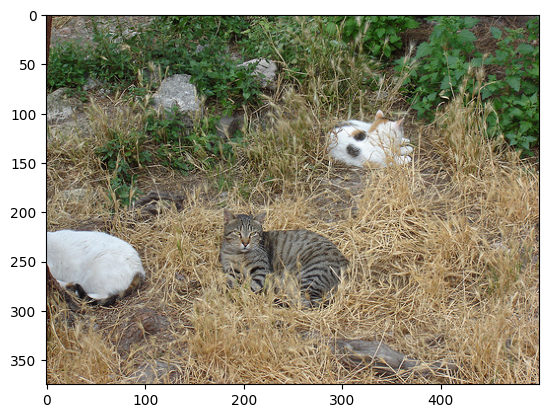

Ground Truth: The three cats , two white with calico accents and a gray tabby , are laying in the brown grass ."
Generated: taking a nap . from her dog . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . hat . """ . """ . """


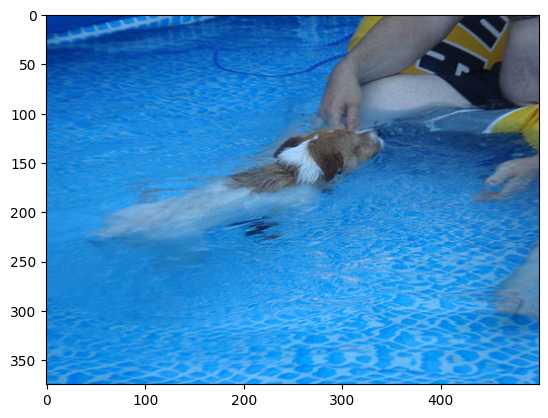

Ground Truth: A dog in a swimming pool swims toward sombody we cannot see .
Generated: water into a dog 's face . """ . <unk> from the <unk> pool table in an orange shirt ." in his right hand ." ." from <unk> ." ." ." ." ." ." ." ." ." ." ." ." ." ." ." ." ." ." ." ." ."


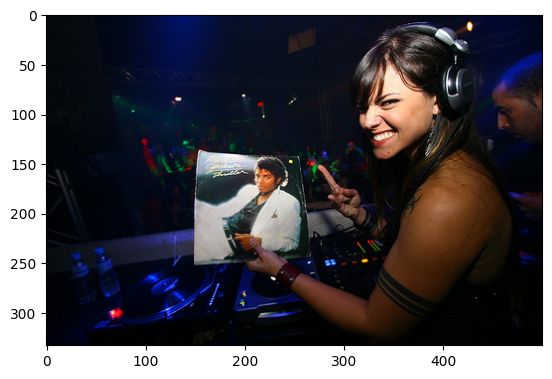

Ground Truth: Girl in club DJ both showing camera the cover of Michael Jackson 's "" Thriller . """
Generated: use a kiss on their makeup . <unk> . <unk> . <unk> . blow a young girl . dance . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """


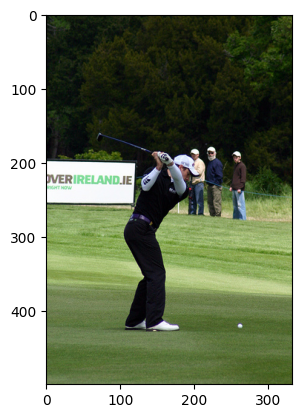

Ground Truth: A golfer wearing black pants and a black shirt swings at a golf ball lying on short cut green grass while three people look on .
Generated: practice in a field . <unk> . out of a baseball game . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ . """ .


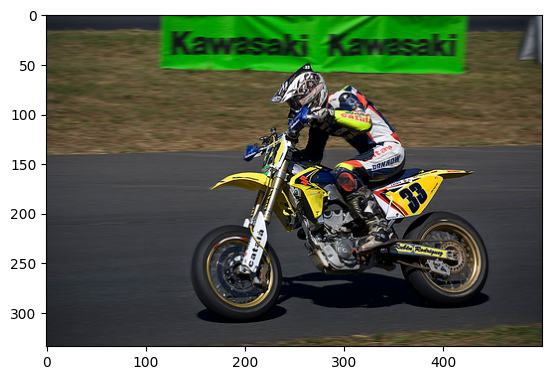

Ground Truth: A motorcycle racer riding a yellow motorcycle with the number 33 is passing a green banner with the Kawasaki logo .
Generated: on a motorcycle . <unk> . <unk> . <unk> on a yellow motorcycle . . """ . . """ . . """ . """ . """ . """ . . """ . """ . . """ . . . . """ . . """ . . """ . .


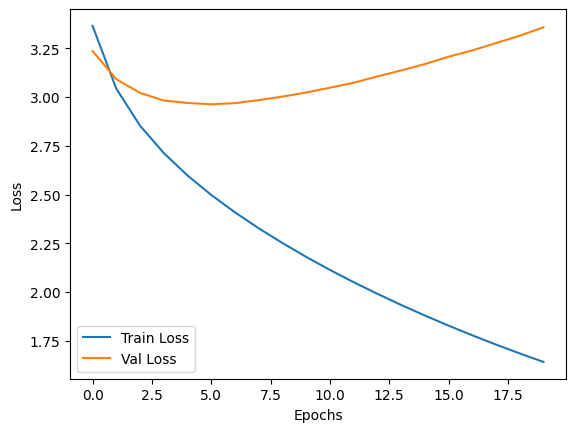

In [74]:

IMAGE_DIR = find_image_dir()  # From provided code
random_test_images = random.sample(test_images, 5)
transform_display = transforms.Compose([transforms.Resize((224, 224))])

for img_name in random_test_images:
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = Image.open(img_path).convert('RGB')
    plt.imshow(img)
    plt.show()
    feature = torch.from_numpy(features_dict[img_name])
    generated = generate_caption(feature, method='beam')
    gt = test_captions[img_name][0]  # One GT for display
    print(f"Ground Truth: {gt}")
    print(f"Generated: {generated}")

# 2. Loss Curve
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [75]:
# 3. Quantitative Evaluation
bleu_scores = []
precision_scores = []  # Using ROUGE as proxy for P/R/F1
recall_scores = []
f1_scores = []
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)
smoother = SmoothingFunction().method4

with torch.no_grad():
    for features, captions, names in tqdm(test_loader):
        features = features.to(device)
        name = names[0]
        generated = generate_caption(features[0].cpu(), method='beam')
        gts = [cap.replace('<start> ', '').replace(' <end>', '').split() for cap in test_captions[name]]
        pred = generated.split()
        bleu = sentence_bleu(gts, pred, smoothing_function=smoother)
        bleu_scores.append(bleu)
        rouge = scorer.score(' '.join(test_captions[name][0].split()), generated)
        precision_scores.append(rouge['rouge1'].precision)
        recall_scores.append(rouge['rouge1'].recall)
        f1_scores.append(rouge['rouge1'].fmeasure)

print(f"Average BLEU-4: {np.mean(bleu_scores):.4f}")
print(f"Average Precision (ROUGE-1): {np.mean(precision_scores):.4f}")
print(f"Average Recall (ROUGE-1): {np.mean(recall_scores):.4f}")
print(f"Average F1 (ROUGE-1): {np.mean(f1_scores):.4f}")


100%|██████████| 13915/13915 [51:04<00:00,  4.54it/s]

Average BLEU-4: 0.0267
Average Precision (ROUGE-1): 0.2237
Average Recall (ROUGE-1): 0.2274
Average F1 (ROUGE-1): 0.2127


In [76]:
# Optional METEOR/ROUGE already included via rouge_scorer

# 4. App Deployment
# Load models for app
encoder.load_state_dict(torch.load('encoder.pth'))
decoder.load_state_dict(torch.load('decoder.pth'))

resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet = nn.DataParallel(resnet).to(device)
resnet.eval()

transform_app = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def predict_image_caption(image):
    image = transform_app(image).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = resnet(image).view(-1).cpu()
    caption = generate_caption(feature, method='beam')
    return caption

demo = gr.Interface(
    fn=predict_image_caption,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Neural Storyteller - Image Captioning"
)
demo.launch(share=True)

/tmp/ipykernel_108/3958041262.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load('encoder.pth'))
/tmp/ipykernel_108/3958041262.py:6: Futu

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9d9baedfafb3296b81.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
